**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 2.4

# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [7]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [8]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


In [9]:
print(x_train_bias)

tensor([[1.0000, 1.0000],
        [1.0000, 0.7143],
        [1.0000, 0.9524],
        [1.0000, 0.2857],
        [1.0000, 0.7619],
        [1.0000, 0.3810],
        [1.0000, 0.6667],
        [1.0000, 0.0000],
        [1.0000, 0.8095],
        [1.0000, 0.1429],
        [1.0000, 0.0476],
        [1.0000, 0.4762],
        [1.0000, 0.5238],
        [1.0000, 0.5714],
        [1.0000, 0.3333],
        [1.0000, 0.8571],
        [1.0000, 0.3333],
        [1.0000, 0.4286],
        [1.0000, 0.6190],
        [1.0000, 0.3333],
        [1.0000, 0.4762],
        [1.0000, 0.5714],
        [1.0000, 0.6667],
        [1.0000, 0.5714],
        [1.0000, 0.7143],
        [1.0000, 0.8095],
        [1.0000, 0.9048],
        [1.0000, 0.8571],
        [1.0000, 0.5238],
        [1.0000, 0.3810],
        [1.0000, 0.2857],
        [1.0000, 0.2857],
        [1.0000, 0.4286],
        [1.0000, 0.5238],
        [1.0000, 0.2381],
        [1.0000, 0.5238],
        [1.0000, 0.8571],
        [1.0000, 0.6667],
        [1.0

## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [10]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

In [11]:
model

Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [12]:
model.weight.data

tensor([[-0.6661, -0.1387]])

In [13]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_38244/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [14]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [15]:
model(xx)

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

In [16]:
model(x_train_bias)

tensor([[-0.0747],
        [-0.0671],
        [-0.0734],
        [-0.0557],
        [-0.0684],
        [-0.0582],
        [-0.0658],
        [-0.0480],
        [-0.0696],
        [-0.0518],
        [-0.0493],
        [-0.0607],
        [-0.0620],
        [-0.0633],
        [-0.0569],
        [-0.0709],
        [-0.0569],
        [-0.0595],
        [-0.0645],
        [-0.0569],
        [-0.0607],
        [-0.0633],
        [-0.0658],
        [-0.0633],
        [-0.0671],
        [-0.0696],
        [-0.0722],
        [-0.0709],
        [-0.0620],
        [-0.0582],
        [-0.0557],
        [-0.0557],
        [-0.0595],
        [-0.0620],
        [-0.0544],
        [-0.0620],
        [-0.0709],
        [-0.0658],
        [-0.0569],
        [-0.0557],
        [-0.0557],
        [-0.0633],
        [-0.0595],
        [-0.0493],
        [-0.0569],
        [-0.0582],
        [-0.0582],
        [-0.0645],
        [-0.0506],
        [-0.0582]], grad_fn=<MmBackward0>)

## Treinamento

In [17]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    #loss cálculo da função de perda
    loss = torch.mean((y_pred - target)**2)

    # backward propagation - cálculo gradient
    loss.backward()

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/100], loss: 0.022983
Epoch[40/100], loss: 0.021432
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


In [18]:
loss.data

tensor(0.0212)

## Avaliação

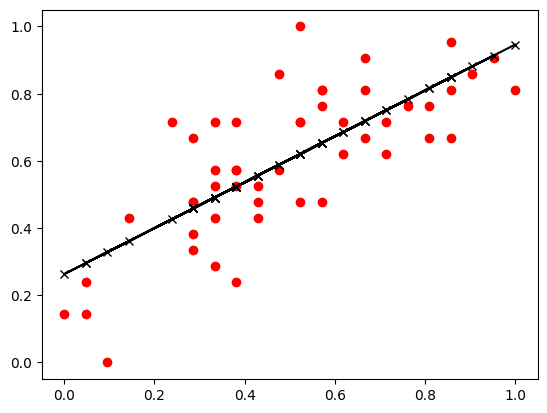

In [19]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [20]:
model.weight.data

tensor([[0.2631, 0.6830]])

In [21]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [22]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   

Resposta:
Em PyTorch, `loss` é um **tensor com grafo de computação** (autograd) anexado.
Usar `loss.data` extrai apenas o **tensor puro de valores**, sem o grafo:

| Expressão   | O que retorna                  |
|-------------|-------------------------------|
| `loss`      | Tensor + grafo de autograd    |
| `loss.data` | Tensor puro (sem grafo)       |
| `loss.item()` | Valor escalar Python        |


- `loss` sozinho ainda carrega referências ao grafo, ocupando memória desnecessariamente ao imprimir.
- `loss.data` é mais leve — só os dados numéricos.
- Não afeta o treinamento, pois é apenas para exibição.

Hoje prefere-se `loss.item()`, que retorna um `float` Python diretamente:

```python
print(f"Loss com item: {loss.item():.4f}")
print(f"Loss com data: {loss.data}")     
```

> `loss.data` era mais comum em versões antigas do PyTorch antes do `.item()` ser introduzido.

In [23]:
print(f"Loss com item: {loss.item():.4f}")
print(f"Loss com data: {loss.data}")

Loss com item: 0.0212
Loss com data: 0.021170221269130707


- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

In [24]:
#Resposta:
y_pred_final = model(x_train_bias)
final_mse_loss = torch.mean((y_pred_final - y_train)**2)
print(f"\n2) Resposta:MSE final com os pesos treinados: {final_mse_loss.item():.6f}")


2) Resposta:MSE final com os pesos treinados: 0.021170


- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.


3) Re-treinando o modelo para capturar a evolução dos parâmetros...


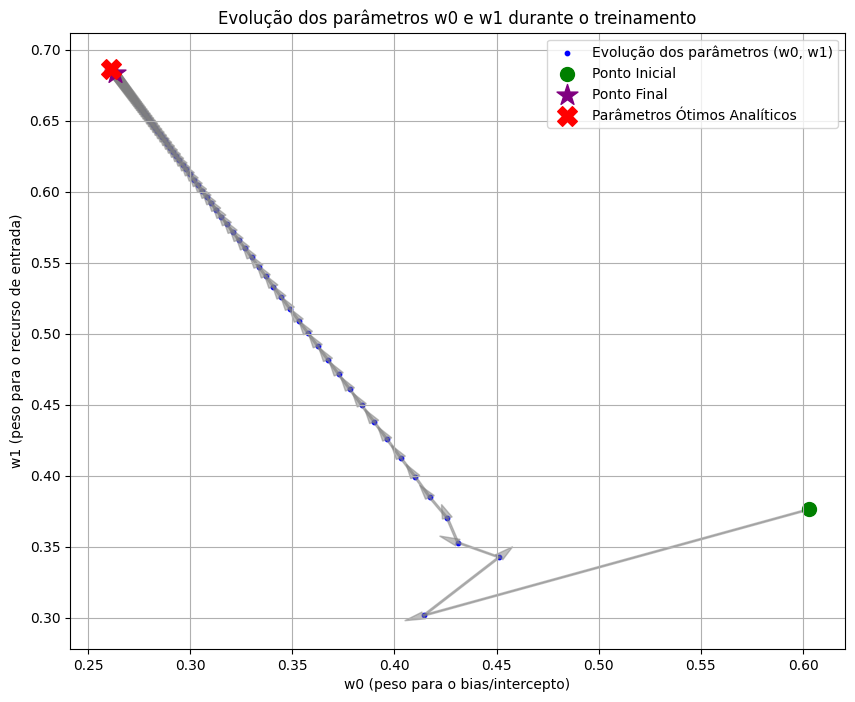

In [25]:
# Para visualizar a evolução dos parâmetros, precisamos re-executar o treinamento
# enquanto salvamos os valores. Re-inicializaremos o modelo para demonstrar a evolução
# desde o início do treinamento.

# Re-inicialização do modelo para o exercício 3
model_q3 = torch.nn.Linear(in_features=2, out_features=1, bias=False)
model_q3.weight.data = torch.zeros(1,2)
torch.nn.init.uniform_(model_q3.weight.data, -0.1, 0.1)

w0_list = []
w1_list = []

num_epochs_q3 = 100 # Usando o mesmo número de epochs do treinamento original
learning_rate_q3 = 0.5 # Usando a mesma taxa de aprendizado do treinamento original

print("\n3) Re-treinando o modelo para capturar a evolução dos parâmetros...")
for epoch_q3 in range(num_epochs_q3):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred_q3 = model_q3(inputs)

    # loss - cálculo da função de perda (MSE)
    loss_q3 = torch.mean((y_pred_q3 - target)**2)

    # backward propagation - cálculo do gradiente
    loss_q3.backward()

    # gradiente descendente - atualização dos pesos
    model_q3.weight.data = model_q3.weight.data - learning_rate_q3 * model_q3.weight.grad.data

    # zeragem dos gradientes para o próximo cálculo
    model_q3.weight.grad.data.zero_()

    # Salvar a evolução dos parâmetros w0 e w1
    w0_list.append(model_q3.weight.data[0, 0].item())
    w1_list.append(model_q3.weight.data[0, 1].item())

# Obter o valor ótimo analítico (calculado anteriormente no notebook, variável 'w_opt')
w_opt_0 = w_opt[0,0].item()
w_opt_1 = w_opt[1,0].item()

plt.figure(figsize=(10, 8))
plt.scatter(w0_list, w1_list, c='blue', label='Evolução dos parâmetros (w0, w1)', s=10)
w0_old = None
w1_old = None
for i in range(len(w0_list)):
    w0, w1 = w0_list[i], w1_list[i]
    if w0_old is not None:
        # Desenha uma seta do ponto anterior para o atual para mostrar a trajetória
        plt.arrow(w0_old, w1_old, w0 - w0_old, w1 - w1_old,
                  head_length=0.01, head_width=0.005, fc='gray', ec='gray', alpha=0.5)
    w0_old, w1_old = w0, w1

# Marcar o ponto inicial (primeiro valor da lista)
plt.scatter(w0_list[0], w1_list[0], c='green', marker='o', s=100, label='Ponto Inicial')
# Marcar o ponto final (último valor da lista)
plt.scatter(w0_list[-1], w1_list[-1], c='purple', marker='*', s=250, label='Ponto Final') # Aumentado o tamanho e alterado o marcador para * para maior visibilidade

# Marcar o valor ótimo analítico
plt.scatter(w_opt_0, w_opt_1, c='red', marker='X', s=200, label='Parâmetros Ótimos Analíticos')

plt.xlabel('w0 (peso para o bias/intercepto)')
plt.ylabel('w1 (peso para o recurso de entrada)')
plt.title('Evolução dos parâmetros w0 e w1 durante o treinamento')
plt.grid(True)
plt.legend()
plt.show()

## Ploting vectors

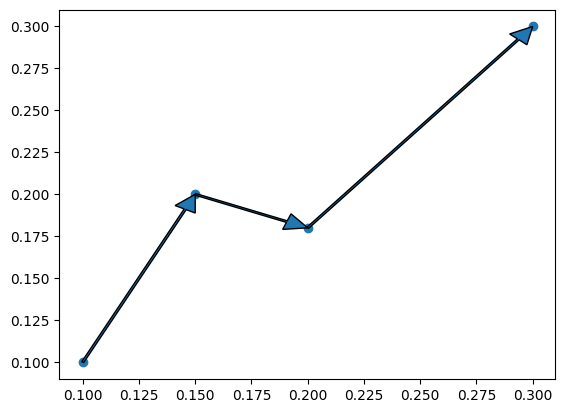

In [26]:
# Exemplo
w0_list = [0.1, 0.15, 0.2, 0.3]
w1_list = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

# Aprendizados